In [3]:
import ee
ee.Authenticate()

Enter verification code:  4/1Ab32j917kK5KeeUNEe0NYciOMak0vK7GITvbpDjXkT0cys2ZGs8qRYRAS-U



Successfully saved authorization token.


In [1]:
import ee
# initialize with Earth Engine project id
gee_project_name = 'ee-gedibio'
ee.Initialize(project=gee_project_name)
import geemap
from geemap import ml
import pickle
import time
import sys
sys.path.append('C:/Users/pj276/Projects/sat_ts_fusion')

from sat_ts_fusion.imagery import lsat_utils
from sat_ts_fusion.ccdc import ccdc_utils
import sat_ts_fusion.fusion.ancillary_covariates as anc_cov

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.oauth2 import service_account
import io
import google.auth
from googleapiclient.errors import HttpError

from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from pprint import pprint
from sklearn.model_selection import RandomizedSearchCV
from pathlib import Path


RefreshError: ('invalid_grant: Bad Request', {'error': 'invalid_grant', 'error_description': 'Bad Request'})

In [6]:
# Set up arguments to help maintain consistency across scripts
args_dict = {'region_geom': 'users/pb463/S2L/Sonoma_cty_v2_PBcleaned',
             'proj_epsg': 'EPSG:3310',
             'grid_scale': 25000,
             'start_year': 2022,
             'end_year': 2024,
             'start_doy': 1,
             'end_doy': 366,
             'max_cloud_cover_land': 50,
             'min_sun_elev': 40,
             'bands': ['blue', 'green', 'red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'NDMI', 'NBR2'],
             'sensors_meta': 'landsat_45789',
             'asset_dir': 'projects/ee-gedibio/assets/ccdc/results/pj_run_test2',
             'pt_fc_id': 'projects/ee-gedibio/assets/ccdc/results/pj_run_test/gediSample',
             'exidpath': '_ext_covs_day_v3',
             'ccdc_seg_bands': ['NBR2', 'NDMI', 'NDVI'],
             'ccdc_syn_bands': ['NIR', 'SWIR1', 'SWIR2'],
             'ccdc_tsin_bands': ['NBR2', 'NDVI'],
             'ccdc_tsin_thresh': [0.1, 0.25],
             'ext_start_year': 2022,
             'ext_end_year': 2024,
             'temporal_match': 'day',
             'annual_date_frac': 0.3315,
             'breakpointBands': ['green','red','NIR','SWIR1','SWIR2'],
             'tmaskBands' : ['green', 'SWIR1'],
             'minObservations': 6,
             'chiSquareProbability': 0.995,
             'minNumOfYearsScaler': 1.33,
             'lambda': 0.005,
             'maxIterations' : 10000,
             'dateFormat' : 1
            }

with open('C:/Users/pj276/Projects/sat_ts_fusion/args.pickle', 'wb') as handle:
    pickle.dump(args_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)
       

In [3]:
# set name of export asset folder (no backslash here), don't forget to change in script body as well
asset_dir = args_dict['asset_dir'] 

# check if export folder exists by listing assets in the parent directory
asset_dir_list = ee.data.listAssets({'parent': asset_dir.rsplit('/', 1)[0]})
asset_dir_list = [i['name'] for i in asset_dir_list['assets']]

# Create asset if it doesn't exist
if not asset_dir in asset_dir_list:
    ee.data.createFolder(asset_dir.rstrip('/'))
# Add backslash here
asset_dir = asset_dir + '/'


In [4]:
# Run script to generate ccdc arrays as assets
%run C:/Users/pj276/Projects/sat_ts_fusion/sat_ts_fusion/ccdc/lsat_ccdc_run_export.py

Submitted task lsatc2sr_ccdc_grid_0
Submitted task lsatc2sr_ccdc_grid_1
Submitted task lsatc2sr_ccdc_grid_2
Submitted task lsatc2sr_ccdc_grid_3
Submitted task lsatc2sr_ccdc_grid_4
Submitted task lsatc2sr_ccdc_grid_5
Submitted task lsatc2sr_ccdc_grid_6
Submitted task lsatc2sr_ccdc_grid_7
Submitted task lsatc2sr_ccdc_grid_8
Submitted task lsatc2sr_ccdc_grid_9
Submitted task lsatc2sr_ccdc_grid_10
Submitted task lsatc2sr_ccdc_grid_11
Submitted task lsatc2sr_ccdc_grid_12
Tasks submitted.
Waiting for tasks to finish.
No more running tasks. Checking task status.
Task status for number 1, task ID YR5OUD4EVURHAI2SUOAMZR4M: COMPLETED
Task status for number 2, task ID VDVRHGEA7PWQQSGOQE25NVSY: COMPLETED
Task status for number 3, task ID WF3A6SFC6SKVUZULP3WWHHMX: COMPLETED
Task status for number 4, task ID LSEIB3QWDDLWY4YIFBUDWVTR: COMPLETED
Task status for number 5, task ID DEGXZKQ32OTQ2UHQCC7JMCTI: COMPLETED
Task status for number 6, task ID LYHMCLPNAAMXBE4F53ZLCP2B: COMPLETED
Task status for nu

In [7]:
# Extract predictor values at point locations and save to drive as csv
%run C:/Users/pj276/Projects/sat_ts_fusion/sat_ts_fusion/fusion/extract_covariates_points.py

Submitted task projects/ee-gedibio/operations/DNZ5DVIMLMM5U5DTBBDR75GK
Tasks submitted.
Waiting for tasks to finish.
No more running tasks. Checking task status.
Task status for number 1, task ID DNZ5DVIMLMM5U5DTBBDR75GK: COMPLETED
Elapsed time 601.3429 seconds


In [25]:
# Get the file ID of the point extract file
def search_file(file_name):
  """Search file in drive location

  Load pre-authorized user credentials from the environment.
  TODO(developer) - See https://developers.google.com/identity
  for guides on implementing OAuth2 for the application.
  """
  creds, _ = google.auth.default()

  try:
    # create drive api client
    service = build("drive", "v3", credentials=creds)
    files = []
    page_token = None
    while True:
      # pylint: disable=maybe-no-member
      response = (
          service.files()
          .list(
              q=f"name contains '{file_name}' and trashed = false",
              spaces="drive",
              fields="nextPageToken, files(id, name)",
              pageToken=page_token,
          )
          .execute()
      )
      for file in response.get("files", []):
        # Process change
        print(f'Found file: {file.get("name")}, {file.get("id")}')
      files.extend(response.get("files", []))
      page_token = response.get("nextPageToken", None)
      if page_token is None:
        break

  except HttpError as error:
    print(f"An error occurred: {error}")
    files = None

  return files
fid = search_file('FCcovariateextracttoAsset2.csv')
file_id = fid[0]['id']

Found file: FCcovariateextracttoAsset2.csv, 1ncpn31BUxwjKPeRpYQ5X9S9tt2vh6yB8


In [26]:
# Pull in the file as bytes and convert to pandas dataframe
def download_file(real_file_id):
  """Downloads a file
  Args:
      real_file_id: ID of the file to download
  Returns : IO object with location.

  Load pre-authorized user credentials from the environment.
  TODO(developer) - See https://developers.google.com/identity
  for guides on implementing OAuth2 for the application.
  """
  creds, _ = google.auth.default()

  try:
    # create drive api client
    service = build("drive", "v3", credentials=creds)

    file_id = real_file_id

    # pylint: disable=maybe-no-member
    request = service.files().get_media(fileId=file_id)
    file = io.BytesIO()
    downloader = MediaIoBaseDownload(file, request)
    done = False
    while done is False:
      status, done = downloader.next_chunk()
      print(f"Download {int(status.progress() * 100)}.")

  except HttpError as error:
    print(f"An error occurred: {error}")
    file = None

  return file.getvalue()

# This downloads file as bytes data
#file_id = '1j-xTgwJOBZsAK_xJTMx-OiSMVCbRPjF5'
aa = download_file(real_file_id=file_id)
df = pd.read_csv(BytesIO(aa))

Download 100.


In [30]:
# Check rh98 for nulls
df['rh98'].isnull().values.any()
# Summarize fields
#df.describe(include='all')
list(df)
# Save to file
df.to_csv('C:/Users/pj276/Data/sattsdf2.csv',index=False)

In [37]:
# Select data fields (i.e. remove geometry and date fields)
dfss = df[['aspect_rad','ccbreak_nbrk_before','ccbreak_tsince_nbr2','ccbreak_tsince_ndvi','ccsegco_NBR2_amp','ccsegco_NBR2_amp2','ccsegco_NBR2_amp3','ccsegco_NBR2_amphratio','ccsegco_NBR2_amphratio2','ccsegco_NBR2_amphratio3','ccsegco_NBR2_cos','ccsegco_NBR2_cos2','ccsegco_NBR2_cos3','ccsegco_NBR2_intp','ccsegco_NBR2_phase','ccsegco_NBR2_phase2','ccsegco_NBR2_phase3','ccsegco_NBR2_sin','ccsegco_NBR2_sin2','ccsegco_NBR2_sin3','ccsegco_NBR2_slp','ccsegco_NDMI_amp','ccsegco_NDMI_amp2','ccsegco_NDMI_amp3','ccsegco_NDMI_amphratio','ccsegco_NDMI_amphratio2','ccsegco_NDMI_amphratio3','ccsegco_NDMI_cos','ccsegco_NDMI_cos2','ccsegco_NDMI_cos3','ccsegco_NDMI_intp','ccsegco_NDMI_phase','ccsegco_NDMI_phase2','ccsegco_NDMI_phase3','ccsegco_NDMI_sin','ccsegco_NDMI_sin2','ccsegco_NDMI_sin3','ccsegco_NDMI_slp','ccsegco_NDVI_amp','ccsegco_NDVI_amp2','ccsegco_NDVI_amp3','ccsegco_NDVI_amphratio','ccsegco_NDVI_amphratio2','ccsegco_NDVI_amphratio3','ccsegco_NDVI_cos','ccsegco_NDVI_cos2','ccsegco_NDVI_cos3','ccsegco_NDVI_intp','ccsegco_NDVI_phase','ccsegco_NDVI_phase2','ccsegco_NDVI_phase3','ccsegco_NDVI_sin','ccsegco_NDVI_sin2','ccsegco_NDVI_sin3','ccsegco_NDVI_slp','ccsynth_NIR','ccsynth_SWIR1','ccsynth_SWIR2','elevation','rh98','slope_rad']]

# Check for fields with NaN values
for i in list(dfss):
    if dfss[i].isna().values.any():
        print(i)

for i in list(dfss):
    if dfss[i].isnull().values.any():
        print(i)

# Subset to promising variables (this is where the variable selection step should go)
ss = ["ccsegco_NDMI_amp","ccsegco_NDVI_intp","slope_rad","ccsegco_NBR2_phase","ccsynth_SWIR2",'rh98']
dfss = df[ss]

                    ccsegco_NDMI_amp  ccsegco_NDVI_intp  slope_rad  \
ccsegco_NDMI_amp            1.000000          -0.518100  -0.465733   
ccsegco_NDVI_intp          -0.518100           1.000000   0.546745   
slope_rad                  -0.465733           0.546745   1.000000   
ccsegco_NBR2_phase         -0.129427           0.081250   0.059628   
ccsynth_SWIR2               0.560095          -0.854711  -0.609721   
rh98                       -0.524470           0.712376   0.585996   

                    ccsegco_NBR2_phase  ccsynth_SWIR2      rh98  
ccsegco_NDMI_amp             -0.129427       0.560095 -0.524470  
ccsegco_NDVI_intp             0.081250      -0.854711  0.712376  
slope_rad                     0.059628      -0.609721  0.585996  
ccsegco_NBR2_phase            1.000000      -0.043985  0.132468  
ccsynth_SWIR2                -0.043985       1.000000 -0.740642  
rh98                          0.132468      -0.740642  1.000000  


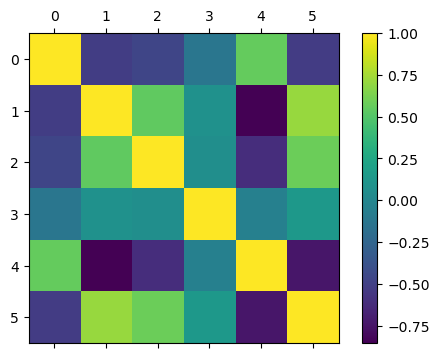

In [38]:
# Calculate correlations
corrM = dfss.corr()
f = plt.figure(figsize=(6, 4))
aa = plt.matshow(corrM, fignum=f.number)
f.colorbar(aa)
print(corrM)

In [39]:
# RF parameter grid
# Number of trees
n_estimators = np.arange(10, 1000, 10)
# Number of features to consider at every split
max_features = ['log2', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
#max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110],
 'max_features': ['log2', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260,
       270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390,
       400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520,
       530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650,
       660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780,
       790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910,
       920, 930, 940, 950, 960, 970, 980, 990])}


In [40]:
# RF paramter tuning
# Empty list to hold rf accuracy values
rfacclist = []
# Empty list to hold best parameters
bps = []

# Copy original dataframe
dfss2 = dfss.copy()

# Separate out y variable
y = dfss2['rh98']

# Drop original y column
dfss2 = dfss2.drop(columns='rh98')

# Create test train split (default is 25/75)
X_train, X_test, y_train, y_test = train_test_split(dfss2, y, test_size=0.25, random_state=42)
print(X_train.shape)

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestRegressor()
# Random search of parameters, using 5 fold cross validation, 
# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = None, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)
# Print the best parameters
print(rf_random.best_params_)
bps.append(rf_random.best_params_)

(116, 5)
Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'n_estimators': np.int64(390), 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}


In [41]:
# Baseline Model Performance
base_model = RandomForestRegressor(n_estimators = 100, max_depth=30, random_state = 42)
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
print("baseline mae")
print(metrics.mean_absolute_error(y_test, base_pred))
print("baseline rmse")
print(np.sqrt(metrics.mean_squared_error(y_test, base_pred)))
# can add r2 vai metrics.r2_score(y_test, best_pred)

# Tuned Model Performance
best_random = rf_random.best_estimator_
best_random.fit(X_train, y_train)
best_pred = best_random.predict(X_test)
print("tuned mae")
print(metrics.mean_absolute_error(y_test, best_pred))
print("tuned rmse")
print(np.sqrt(metrics.mean_squared_error(y_test, best_pred)))

baseline mae
5.731328351232536
baseline rmse
8.412767696017855
tuned mae
5.638671525511782
tuned rmse
8.188877292108156


(116, 5)
mean_absolute_error:  5.675068714475945
mean_squared_error:  8.172285687272238


Text(0.5, 1.0, 'Permutation Importance')

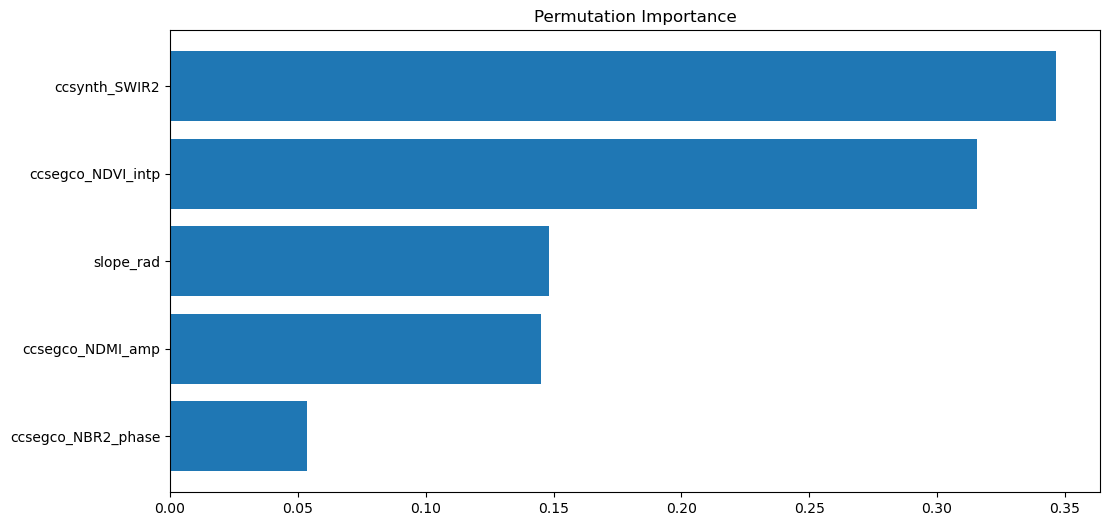

In [42]:
# Fit model using optimized hyperparameters
# Copy original dataframe
dfss2 = dfss.copy()

# Separate out y variable
y = dfss2['rh98']

# Drop original y column
dfss2 = dfss2.drop(columns='rh98')

# Create test train split (default is 25/75)
X_train, X_test, y_train, y_test = train_test_split(dfss2, y, test_size=0.25, random_state=42)
print(X_train.shape)

clf = RandomForestRegressor(n_estimators=bps[0]['n_estimators'], max_depth=bps[0]['max_depth'], max_features=bps[0]['max_features'], min_samples_split=bps[0]['min_samples_split'],
                            min_samples_leaf=bps[0]['min_samples_leaf'], bootstrap=bps[0]['bootstrap'])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Add accuracy values to dataframe
a1 = pd.DataFrame({'col_name': ['mean_absolute_error'],'accuracy val': [metrics.mean_absolute_error(y_test, y_pred)]})
a2 = pd.DataFrame({'col_name': ['mean_squared_error'],'accuracy val': [np.sqrt(metrics.mean_squared_error(y_test, y_pred))]})

accdf = pd.concat([a1,a2]).reset_index(drop=True)

print("mean_absolute_error: ", metrics.mean_absolute_error(y_test, y_pred))
print("mean_squared_error: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# Run RF on full dataset for shapley values
clf = RandomForestRegressor(n_estimators=bps[0]['n_estimators'], max_depth=bps[0]['max_depth'], max_features=bps[0]['max_features'], min_samples_split=bps[0]['min_samples_split'],
                            min_samples_leaf=bps[0]['min_samples_leaf'], bootstrap=bps[0]['bootstrap'])
clf.fit(dfss2, y)

pi = permutation_importance(clf, dfss2, y, n_repeats=10,random_state=0)
sorted_idx = pi.importances_mean.argsort()
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), pi.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_test.columns)[sorted_idx])
plt.title('Permutation Importance')
#plt.savefig(fpath + s.replace('.', '_') + '_mammal_pi.png')
#plt.close()


<Axes: ylabel='Density'>

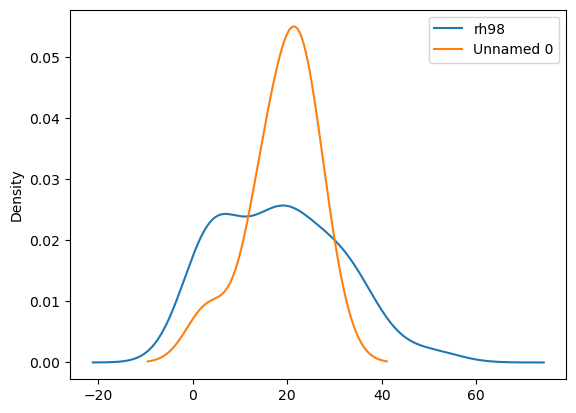

In [43]:
# Plot distribution of predicted and observed heights
pd.DataFrame([y_test,y_pred]).T.plot(kind='density')

In [48]:
# convert sklearn rf output to strings that can be used with gee
trees = ml.rf_to_strings(clf, list(dfss2), output_mode="REGRESSION")
# create a ee classifier to use with ee objects from the trees
ee_classifier = ml.strings_to_classifier(trees)

In [49]:
# Create a predictor stack to which the fitted RF model will be applied
ccdc_result_path=args_dict['asset_dir'] #'projects/ee-gedibio/assets/ccdc/results/pj_run_test/'
year_frac = 2024.5
ccdc_seg_bands = args_dict['ccdc_seg_bands'] #['NBR2', 'NDMI', 'NDVI']
ccdc_syn_bands = args_dict['ccdc_syn_bands'] #['NIR', 'SWIR1', 'SWIR2']
ccdc_tsin_bands = args_dict['ccdc_tsin_bands'] #['NBR2', 'NDVI']
ccdc_tsin_thresh = args_dict['ccdc_tsin_thresh'] #[0.1, 0.25]
ccdc_start_year = args_dict['start_year'] #2022

# make the CCDC mosaic image
ccdc_img = ccdc_utils.mosaic_ccdc_img_tiles(ccdc_result_path)

# make the ancillary covariate image (only elev, slope, and aspect in this case)
anc_cov_img = anc_cov.make_covar_topo_stack()

# CCDC segment coefficients
ccdc_seg_coefs = ccdc_utils.get_segment_coefs(ccdc_img=ccdc_img, year_frac=year_frac,
                                              bands=ccdc_seg_bands, normalize=True, use_next=False)
# CCDC segment phase and amplitude
ccdc_seg_phamp = ccdc_utils.get_segment_phase_amp(coefs_img=ccdc_seg_coefs)

# CCDC synthetic values
ccdc_syn_vals = ccdc_utils.get_synthetic(ccdc_img=ccdc_img, year_frac=year_frac,
                                         bands=ccdc_syn_bands)
# CCDC segment breaks
# number of breaks before the site observation
ccdc_n_breaks_before = ccdc_utils.get_n_breaks_img(ccdc_img=ccdc_img,
                                                   start_year=ccdc_start_year,
                                                   year_frac=year_frac).rename('ccbreak_nbrk_before')

ccdc_time_since = ccdc_utils.get_time_since_largest_mag_break_bands(ccdc_img=ccdc_img, start_year=ccdc_start_year,
                                                                    year_frac=year_frac, bands_list=ccdc_tsin_bands,
                                                                    thresh_list=ccdc_tsin_thresh)

# combine all images into one, including ancillary covariates
cov_stack = ee.Image.cat([ccdc_seg_coefs, ccdc_seg_phamp, ccdc_syn_vals,
                          ccdc_n_breaks_before,
                          ccdc_time_since,
                          anc_cov_img])

# select variables used in the RF model
cov_stack = cov_stack.select(["ccsegco_NDMI_amp","ccsegco_NDVI_intp","slope_rad","ccsegco_NBR2_phase","ccsynth_SWIR2"])
#print(cov_stack.bandNames().getInfo())

In [53]:
# Predict height
classified = cov_stack.classify(ee_classifier)

In [54]:
# Visualize
Map = geemap.Map(center=(40, -100), zoom=4)
Map.add_basemap("SATELLITE")
Map
Map.addLayer(classified)

Map(center=[40, -100], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(ch…